
# REFUGE Cup & Disc Segmentation  
## U-Net + EfficientNetB4 Encoder

Notebook ini digunakan untuk melatih model segmentasi **optic cup** dan **optic disc** dari dataset REFUGE.

Struktur folder input:

```text
/content/drive/MyDrive/REFUGE101/BV_CDR/
└── REFUG_raw/
    ├── images/
    ├── masks_cup/
    └── masks_disc/
```

Output hasil prediksi akan disimpan ke:

```text
/content/drive/MyDrive/REFUGE101/BV_CDR/pred_mask_cup_disc_efficientnetb4/
├── pred_cup/
├── pred_disc/
├── best_model/
├── previews/
├── splits/
└── metrics/
```

Model:
- Encoder: **EfficientNetB4 pretrained ImageNet**
- Decoder: **U-Net decoder**
- Output: 2 channel mask
  - channel 0 = cup
  - channel 1 = disc

Catatan: EfficientNetB4 lebih berat dibanding EfficientNetB0/ResNet50. Jika GPU T4 OOM, turunkan `BATCH_SIZE` menjadi 1.


In [ ]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:

!pip -q install openpyxl scikit-learn


In [ ]:

import os
import glob
import random
import json
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]



## 1. Konfigurasi path dan parameter training


In [ ]:
# =========================
# CONFIG
# =========================
# Sesuaikan jika folder Drive kamu berbeda.
BASE_DIR = "/content/drive/MyDrive/REFUGE101/BV_CDR"

# Encoder yang digunakan pada notebook ini
ENCODER_TYPE = "efficientnetb4"

REFUGE_RAW_DIR = os.path.join(BASE_DIR, "REFUG_raw")
IMAGE_DIR = os.path.join(REFUGE_RAW_DIR, "images")
CUP_DIR = os.path.join(REFUGE_RAW_DIR, "masks_cup")
DISC_DIR = os.path.join(REFUGE_RAW_DIR, "masks_disc")

# Output dibuat berbeda agar tidak menimpa hasil encoder lain
OUT_DIR = os.path.join(BASE_DIR, f"pred_mask_cup_disc_{ENCODER_TYPE}")
PRED_CUP_DIR = os.path.join(OUT_DIR, "pred_cup")
PRED_DISC_DIR = os.path.join(OUT_DIR, "pred_disc")
BEST_MODEL_DIR = os.path.join(OUT_DIR, "best_model")
PREVIEW_DIR = os.path.join(OUT_DIR, "previews")
SPLIT_DIR = os.path.join(OUT_DIR, "splits")
METRIC_DIR = os.path.join(OUT_DIR, "metrics")
PLOT_DIR = os.path.join(OUT_DIR, "plots")

for p in [
    OUT_DIR,
    PRED_CUP_DIR,
    PRED_DISC_DIR,
    BEST_MODEL_DIR,
    PREVIEW_DIR,
    SPLIT_DIR,
    METRIC_DIR,
    PLOT_DIR
]:
    os.makedirs(p, exist_ok=True)

# Ukuran input model
IMG_SIZE = 512

# EfficientNetB4 lebih berat. Jika OOM, turunkan menjadi 1.
BATCH_SIZE = 2

EPOCHS = 60
LEARNING_RATE = 1e-4

BEST_MODEL_PATH = os.path.join(BEST_MODEL_DIR, f"best_unet_{ENCODER_TYPE}_cup_disc.keras")
LAST_MODEL_PATH = os.path.join(BEST_MODEL_DIR, f"last_unet_{ENCODER_TYPE}_cup_disc.keras")

print("ENCODER_TYPE:", ENCODER_TYPE)
print("IMAGE_DIR:", IMAGE_DIR)
print("CUP_DIR:", CUP_DIR)
print("DISC_DIR:", DISC_DIR)
print("OUT_DIR:", OUT_DIR)
print("BEST_MODEL_PATH:", BEST_MODEL_PATH)


IMAGE_DIR: /content/drive/MyDrive/BV_CDR/REFUG_raw/images
CUP_DIR: /content/drive/MyDrive/BV_CDR/REFUG_raw/masks_cup
DISC_DIR: /content/drive/MyDrive/BV_CDR/REFUG_raw/masks_disc
OUT_DIR: /content/drive/MyDrive/BV_CDR/pred_mask_cup_disc
BEST_MODEL_PATH: /content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/best_model/best_unet_resnet50_cup_disc.keras



## 2. Cek pasangan image, mask cup, dan mask disc

Nama file pada `images`, `masks_cup`, dan `masks_disc` harus sama.


In [ ]:

assert os.path.exists(IMAGE_DIR), f"Folder images tidak ditemukan: {IMAGE_DIR}"
assert os.path.exists(CUP_DIR), f"Folder masks_cup tidak ditemukan: {CUP_DIR}"
assert os.path.exists(DISC_DIR), f"Folder masks_disc tidak ditemukan: {DISC_DIR}"

def stem(path):
    return os.path.splitext(os.path.basename(path))[0]

image_dict = {
    stem(p): p for p in glob.glob(os.path.join(IMAGE_DIR, "*"))
    if os.path.isfile(p)
}

cup_dict = {
    stem(p): p for p in glob.glob(os.path.join(CUP_DIR, "*"))
    if os.path.isfile(p)
}

disc_dict = {
    stem(p): p for p in glob.glob(os.path.join(DISC_DIR, "*"))
    if os.path.isfile(p)
}

names = sorted(list(set(image_dict.keys()) & set(cup_dict.keys()) & set(disc_dict.keys())))

missing_image = sorted(list((set(cup_dict.keys()) | set(disc_dict.keys())) - set(image_dict.keys())))
missing_cup = sorted(list(set(image_dict.keys()) - set(cup_dict.keys())))
missing_disc = sorted(list(set(image_dict.keys()) - set(disc_dict.keys())))

print("Jumlah image:", len(image_dict))
print("Jumlah cup mask:", len(cup_dict))
print("Jumlah disc mask:", len(disc_dict))
print("Jumlah pasangan lengkap:", len(names))
print("Missing image:", len(missing_image))
print("Missing cup:", len(missing_cup))
print("Missing disc:", len(missing_disc))

if len(missing_cup) > 0:
    print("Contoh missing cup:", missing_cup[:10])

if len(missing_disc) > 0:
    print("Contoh missing disc:", missing_disc[:10])

rows = []
for name in names:
    rows.append({
        "name_no_ext": name,
        "filename": os.path.basename(image_dict[name]),
        "image_path": image_dict[name],
        "cup_path": cup_dict[name],
        "disc_path": disc_dict[name]
    })

pairs_df = pd.DataFrame(rows)
pairs_csv_path = os.path.join(SPLIT_DIR, "all_pairs_cup_disc.csv")
pairs_df.to_csv(pairs_csv_path, index=False)

print("Saved all pairs:", pairs_csv_path)
pairs_df.head()


Jumlah image: 400
Jumlah cup mask: 400
Jumlah disc mask: 400
Jumlah pasangan lengkap: 400
Missing image: 0
Missing cup: 0
Missing disc: 0
Saved all pairs: /content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/splits/all_pairs_cup_disc.csv


,name_no_ext,filename,image_path,cup_path,disc_path
0,REFUGE1-train-1,REFUGE1-train-1.png,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/REFUG_raw/masks_...,/content/drive/MyDrive/BV_CDR/REFUG_raw/masks_...
1,REFUGE1-train-10,REFUGE1-train-10.png,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/REFUG_raw/masks_...,/content/drive/MyDrive/BV_CDR/REFUG_raw/masks_...
2,REFUGE1-train-100,REFUGE1-train-100.png,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/REFUG_raw/masks_...,/content/drive/MyDrive/BV_CDR/REFUG_raw/masks_...
3,REFUGE1-train-101,REFUGE1-train-101.png,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/REFUG_raw/masks_...,/content/drive/MyDrive/BV_CDR/REFUG_raw/masks_...
4,REFUGE1-train-102,REFUGE1-train-102.png,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/REFUG_raw/masks_...,/content/drive/MyDrive/BV_CDR/REFUG_raw/masks_...



## 3. Split train, validation, dan test

Untuk segmentasi, notebook ini memakai split:
- 70% train
- 15% validation
- 15% test


In [ ]:

train_df, temp_df = train_test_split(
    pairs_df,
    test_size=0.30,
    random_state=SEED,
    shuffle=True
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    shuffle=True
)

train_path = os.path.join(SPLIT_DIR, "train_cup_disc.csv")
val_path = os.path.join(SPLIT_DIR, "val_cup_disc.csv")
test_path = os.path.join(SPLIT_DIR, "test_cup_disc.csv")

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

print("Train:", len(train_df), train_path)
print("Val:", len(val_df), val_path)
print("Test:", len(test_df), test_path)


Train: 280 /content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/splits/train_cup_disc.csv
Val: 60 /content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/splits/val_cup_disc.csv
Test: 60 /content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/splits/test_cup_disc.csv



## 4. Preview image dan mask asli


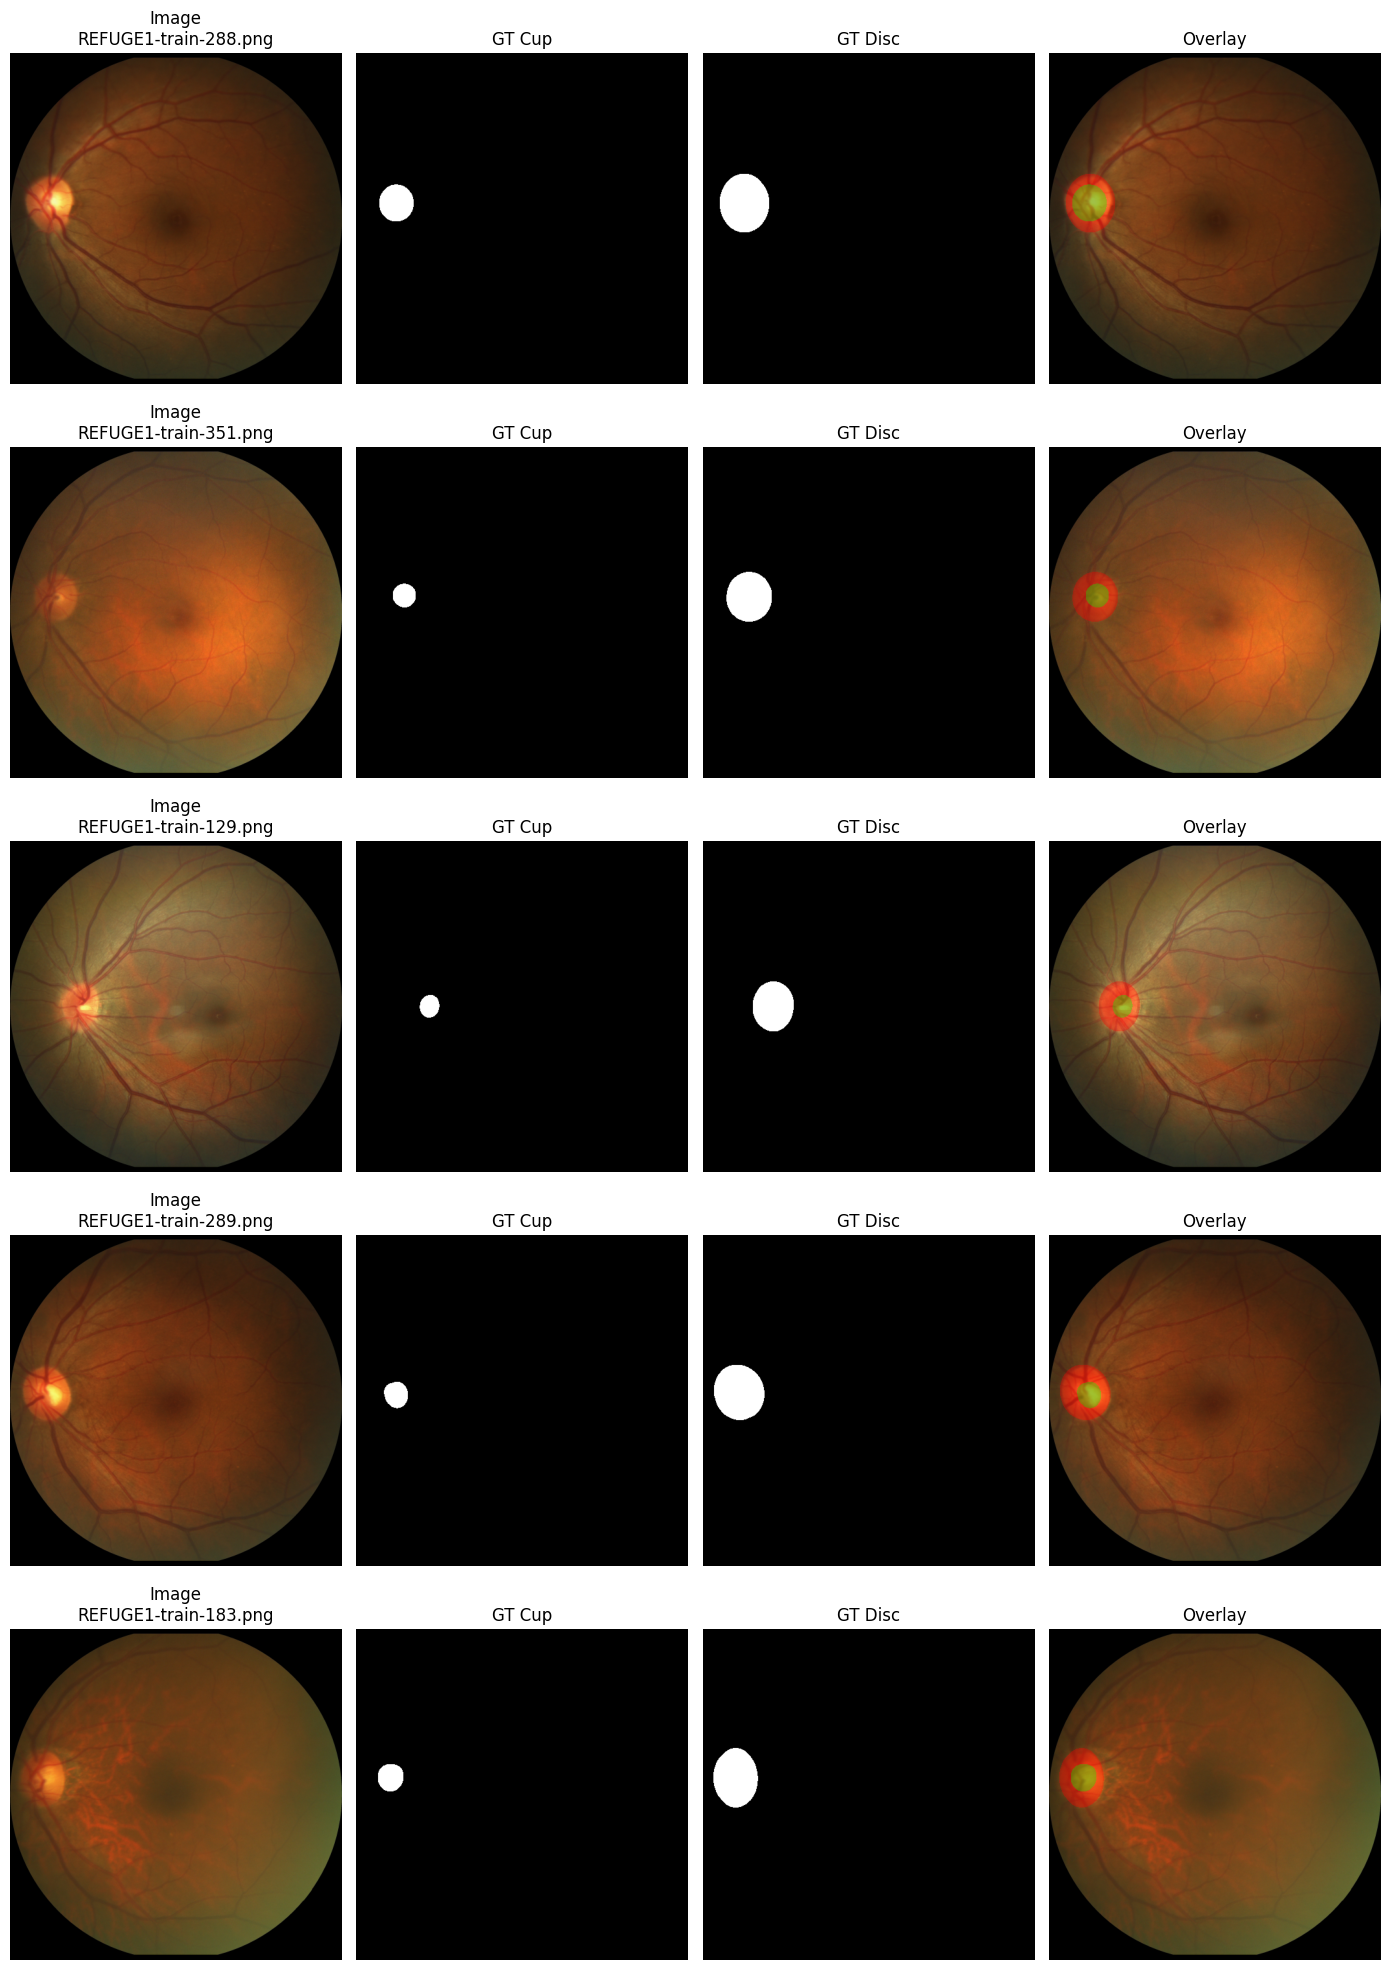

In [ ]:

def read_rgb_cv(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Gagal membaca image: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def read_gray_cv(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Gagal membaca mask: {path}")
    return img

def binarize(mask):
    return (mask > 0).astype(np.uint8)

sample_df = pairs_df.sample(n=min(5, len(pairs_df)), random_state=SEED)

plt.figure(figsize=(14, 4 * len(sample_df)))

for i, row in enumerate(sample_df.itertuples(index=False), start=1):
    img = read_rgb_cv(row.image_path)
    cup = binarize(read_gray_cv(row.cup_path))
    disc = binarize(read_gray_cv(row.disc_path))

    overlay = img.copy()
    overlay[disc > 0] = (0.65 * overlay[disc > 0] + 0.35 * np.array([255, 0, 0])).astype(np.uint8)
    overlay[cup > 0] = (0.65 * overlay[cup > 0] + 0.35 * np.array([0, 255, 0])).astype(np.uint8)

    plt.subplot(len(sample_df), 4, (i-1)*4 + 1)
    plt.imshow(img)
    plt.title(f"Image\n{row.filename}")
    plt.axis("off")

    plt.subplot(len(sample_df), 4, (i-1)*4 + 2)
    plt.imshow(cup, cmap="gray")
    plt.title("GT Cup")
    plt.axis("off")

    plt.subplot(len(sample_df), 4, (i-1)*4 + 3)
    plt.imshow(disc, cmap="gray")
    plt.title("GT Disc")
    plt.axis("off")

    plt.subplot(len(sample_df), 4, (i-1)*4 + 4)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

plt.tight_layout()
plt.show()



## 5. Dataset loader dan augmentasi

Mask output dibuat 2 channel:

```text
channel 0 = cup
channel 1 = disc
```


In [ ]:

def decode_image(path, channels=3):
    data = tf.io.read_file(path)
    img = tf.image.decode_image(data, channels=channels, expand_animations=False)
    img.set_shape([None, None, channels])
    return img

def load_sample(image_path, cup_path, disc_path):
    image = decode_image(image_path, channels=3)
    cup = decode_image(cup_path, channels=1)
    disc = decode_image(disc_path, channels=1)

    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE], method="bilinear")
    cup = tf.image.resize(cup, [IMG_SIZE, IMG_SIZE], method="nearest")
    disc = tf.image.resize(disc, [IMG_SIZE, IMG_SIZE], method="nearest")

    image = tf.cast(image, tf.float32)
    cup = tf.cast(cup > 0, tf.float32)
    disc = tf.cast(disc > 0, tf.float32)

    mask = tf.concat([cup, disc], axis=-1)
    return image, mask

def augment_sample(image, mask):
    do_flip = tf.random.uniform(()) > 0.5
    image = tf.cond(do_flip, lambda: tf.image.flip_left_right(image), lambda: image)
    mask = tf.cond(do_flip, lambda: tf.image.flip_left_right(mask), lambda: mask)

    image = tf.image.random_brightness(image, max_delta=8.0)
    image = tf.image.random_contrast(image, lower=0.90, upper=1.10)
    image = tf.clip_by_value(image, 0.0, 255.0)

    return image, mask

def make_dataset(df, batch_size=4, training=False):
    image_paths = df["image_path"].values
    cup_paths = df["cup_path"].values
    disc_paths = df["disc_path"].values

    ds = tf.data.Dataset.from_tensor_slices((image_paths, cup_paths, disc_paths))
    ds = ds.map(load_sample, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(augment_sample, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, BATCH_SIZE, training=True)
val_ds = make_dataset(val_df, BATCH_SIZE, training=False)
test_ds = make_dataset(test_df, BATCH_SIZE, training=False)

for img_batch, mask_batch in train_ds.take(1):
    print("Image batch:", img_batch.shape, img_batch.dtype, tf.reduce_min(img_batch).numpy(), tf.reduce_max(img_batch).numpy())
    print("Mask batch:", mask_batch.shape, mask_batch.dtype, tf.reduce_min(mask_batch).numpy(), tf.reduce_max(mask_batch).numpy())


Image batch: (4, 512, 512, 3) <dtype: 'float32'> 0.0 255.0
Mask batch: (4, 512, 512, 2) <dtype: 'float32'> 0.0 1.0



## 6. Loss dan metrik segmentasi

Loss yang dipakai:
- Binary Cross Entropy
- Dice Loss

Total loss:

```text
loss = BCE + Dice Loss
```


In [ ]:

SMOOTH = 1e-6

def dice_coef(y_true, y_pred):
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(tf.cast(y_pred, tf.float32), [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + SMOOTH) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + SMOOTH
    )

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    bce = tf.reduce_mean(bce)
    return bce + dice_loss(y_true, y_pred)

def iou_coef(y_true, y_pred):
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(tf.cast(y_pred, tf.float32), [-1])
    y_pred_f = tf.cast(y_pred_f > 0.5, tf.float32)

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + SMOOTH) / (union + SMOOTH)

def dice_cup(y_true, y_pred):
    return dice_coef(y_true[..., 0:1], y_pred[..., 0:1])

def dice_disc(y_true, y_pred):
    return dice_coef(y_true[..., 1:2], y_pred[..., 1:2])

def iou_cup(y_true, y_pred):
    return iou_coef(y_true[..., 0:1], y_pred[..., 0:1])

def iou_disc(y_true, y_pred):
    return iou_coef(y_true[..., 1:2], y_pred[..., 1:2])



## 7. Model U-Net + EfficientNetB4 Encoder

Skip connection yang dipakai dari EfficientNetB4:
- `block1b_add` untuk fitur resolusi 256×256
- `block2d_add` untuk fitur resolusi 128×128
- `block3d_add` untuk fitur resolusi 64×64
- `block4f_add` untuk fitur resolusi 32×32

Bottleneck:
- `top_activation` untuk fitur resolusi 16×16


In [ ]:
def conv_block(x, filters, name):
    x = layers.Conv2D(filters, 3, padding="same", name=f"{name}_conv1")(x)
    x = layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = layers.Activation("relu", name=f"{name}_relu1")(x)

    x = layers.Conv2D(filters, 3, padding="same", name=f"{name}_conv2")(x)
    x = layers.BatchNormalization(name=f"{name}_bn2")(x)
    x = layers.Activation("relu", name=f"{name}_relu2")(x)
    return x


def decoder_block(x, skip, filters, name):
    x = layers.UpSampling2D(
        (2, 2),
        interpolation="bilinear",
        name=f"{name}_upsample"
    )(x)

    if skip is not None:
        x = layers.Concatenate(name=f"{name}_concat")([x, skip])

    x = conv_block(x, filters, name=f"{name}_convblock")
    return x


def build_unet_efficientnetb4(input_shape=(512, 512, 3), num_classes=2):
    inputs = keras.Input(shape=input_shape, name="image_input")

    # EfficientNet pada tf.keras sudah memiliki preprocessing internal.
    # Input dari dataset tetap dalam rentang 0-255 seperti notebook encoder lain.
    encoder = keras.applications.EfficientNetB4(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs
    )

    # Skip connection EfficientNetB4 untuk input 512x512
    # s1 = 256x256, s2 = 128x128, s3 = 64x64, s4 = 32x32, bottleneck = 16x16
    s1 = encoder.get_layer("block1b_add").output
    s2 = encoder.get_layer("block2d_add").output
    s3 = encoder.get_layer("block3d_add").output
    s4 = encoder.get_layer("block4f_add").output
    b1 = encoder.get_layer("top_activation").output

    d1 = decoder_block(b1, s4, 512, "decoder1")
    d2 = decoder_block(d1, s3, 256, "decoder2")
    d3 = decoder_block(d2, s2, 128, "decoder3")
    d4 = decoder_block(d3, s1, 64, "decoder4")
    d5 = decoder_block(d4, None, 32, "decoder5")

    outputs = layers.Conv2D(
        num_classes,
        kernel_size=1,
        padding="same",
        activation="sigmoid",
        name="cup_disc_output"
    )(d5)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="UNet_EfficientNetB4_CupDisc"
    )
    return model


model = build_unet_efficientnetb4(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=2
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=bce_dice_loss,
    metrics=[
        dice_coef,
        dice_cup,
        dice_disc,
        iou_coef,
        iou_cup,
        iou_disc
    ]
)

model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "UNet_ResNet50_CupDisc"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 512, 512)  │          0 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 512, 512)  │          0 │ image_input[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 512, 512)  │          0 │ image_input[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 512, 512,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 512, 512,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 518, 518,  │          0 │ add[0][0]         │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 256, 256,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 256, 256,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 256, 256,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 258, 258,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 128, 128,  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 128, 128,  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 128, 128,  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 128, 128,  │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 128, 128,  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 128, 128,  │        256 │ conv2_block1_2_c

 Total params: 43,974,274 (167.75 MB)

 Trainable params: 43,917,186 (167.53 MB)

 Non-trainable params: 57,088 (223.00 KB)


## 8. Training model

Model terbaik disimpan ke folder output EfficientNetB4:

```text
/content/drive/MyDrive/REFUGE101/BV_CDR/pred_mask_cup_disc_efficientnetb4/best_model/best_unet_efficientnetb4_cup_disc.keras
```


In [ ]:

callbacks = [
    keras.callbacks.ModelCheckpoint(
        BEST_MODEL_PATH,
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_dice_coef",
        mode="max",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_dice_coef",
        mode="max",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

model.save(LAST_MODEL_PATH)
print("Best model saved:", BEST_MODEL_PATH)
print("Last model saved:", LAST_MODEL_PATH)


Epoch 1/60
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - dice_coef: 0.0442 - dice_cup: 0.0196 - dice_disc: 0.0690 - iou_coef: 0.1958 - iou_cup: 0.1416 - iou_disc: 0.2330 - loss: 1.5754
Epoch 1: val_dice_coef improved from None to 0.03416, saving model to /content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/best_model/best_unet_resnet50_cup_disc.keras

Epoch 1: finished saving model to /content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/best_model/best_unet_resnet50_cup_disc.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 219s 1s/step - dice_coef: 0.0530 - dice_cup: 0.0229 - dice_disc: 0.0828 - iou_coef: 0.4266 - iou_cup: 0.3504 - iou_disc: 0.4636 - loss: 1.4340 - val_dice_coef: 0.0342 - val_dice_cup: 0.0168 - val_dice_disc: 0.0458 - val_iou_coef: 0.0149 - val_iou_cup: 0.0099 - val_iou_disc: 0.0171 - val_loss: 2.0762 - learning_rate: 1.0000e-04
Epoch 2/60
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - dice_coef: 0.0662 - dice_cup: 0.0273 - dice_disc: 0.1027 - iou_coef: 0.7676 - iou_cup: 0.6909 - iou_disc: 0.7892 - 


## 9. Plot training history


History saved: /content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/metrics/training_history_unet_resnet50_cup_disc.csv


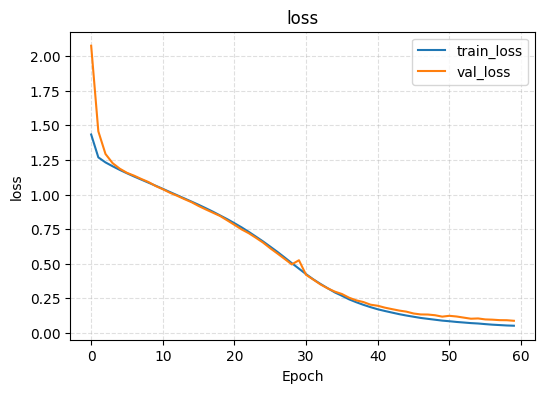

Saved: /content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/plots/loss.png


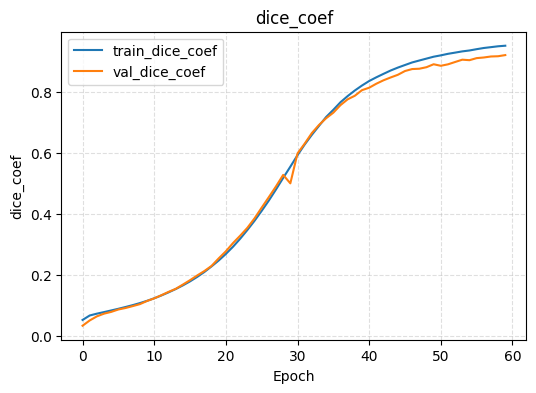

Saved: /content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/plots/dice_coef.png


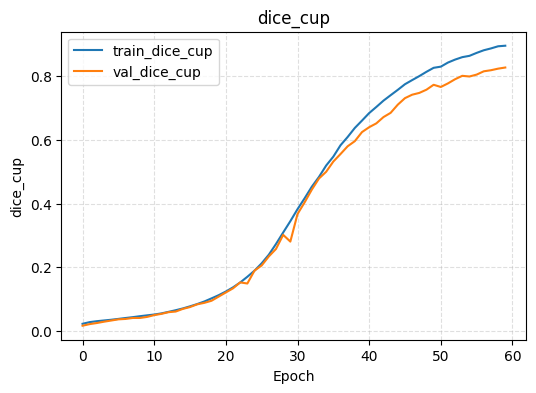

Saved: /content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/plots/dice_cup.png


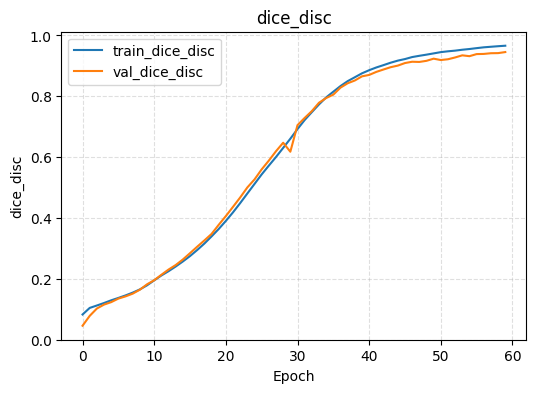

Saved: /content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/plots/dice_disc.png


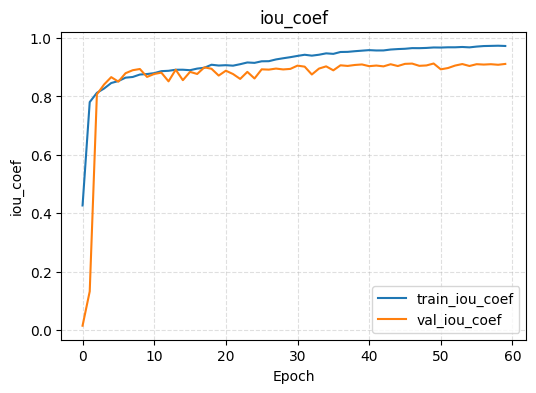

Saved: /content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/plots/iou_coef.png


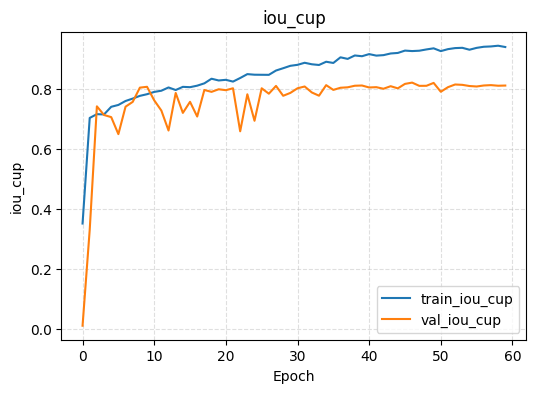

Saved: /content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/plots/iou_cup.png


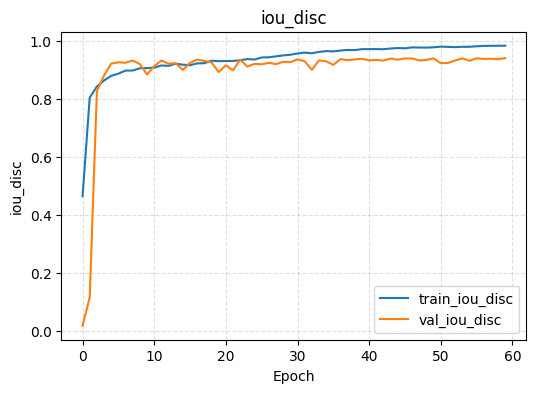

Saved: /content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/plots/iou_disc.png


In [ ]:

hist_df = pd.DataFrame(history.history)
history_csv_path = os.path.join(METRIC_DIR, f"training_history_unet_{ENCODER_TYPE}_cup_disc.csv")
hist_df.to_csv(history_csv_path, index=False)
print("History saved:", history_csv_path)

metrics_to_plot = [
    "loss",
    "dice_coef",
    "dice_cup",
    "dice_disc",
    "iou_coef",
    "iou_cup",
    "iou_disc"
]

for m in metrics_to_plot:
    if m in hist_df.columns and f"val_{m}" in hist_df.columns:
        plt.figure(figsize=(6, 4))
        plt.plot(hist_df[m], label=f"train_{m}")
        plt.plot(hist_df[f"val_{m}"], label=f"val_{m}")
        plt.title(m)
        plt.xlabel("Epoch")
        plt.ylabel(m)
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.4)
        save_path = os.path.join(PLOT_DIR, f"{m}.png")
        plt.savefig(save_path, dpi=180, bbox_inches="tight")
        plt.show()
        print("Saved:", save_path)




## 10. Evaluasi pada test set


In [ ]:
best_model = keras.models.load_model(
    BEST_MODEL_PATH,
    custom_objects={
        "bce_dice_loss": bce_dice_loss,
        "dice_coef": dice_coef,
        "dice_cup": dice_cup,
        "dice_disc": dice_disc,
        "iou_coef": iou_coef,
        "iou_cup": iou_cup,
        "iou_disc": iou_disc
    }
)

test_result = best_model.evaluate(test_ds, verbose=1)

# Pada beberapa versi Keras, metrics_names dapat terbaca sebagai compile_metrics.
# Karena itu nama metrik dibuat manual agar file JSON lengkap.
metric_names = [
    "loss",
    "dice_coef",
    "dice_cup",
    "dice_disc",
    "iou_coef",
    "iou_cup",
    "iou_disc"
]

test_metrics = dict(zip(metric_names, test_result))

test_metrics_path = os.path.join(METRIC_DIR, f"test_metrics_unet_{ENCODER_TYPE}_cup_disc.json")
with open(test_metrics_path, "w") as f:
    json.dump({k: float(v) for k, v in test_metrics.items()}, f, indent=4)

print("Test metrics:")
print(json.dumps({k: float(v) for k, v in test_metrics.items()}, indent=4))
print("Saved:", test_metrics_path)


15/15 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - dice_coef: 0.9127 - dice_cup: 0.8162 - dice_disc: 0.9401 - iou_coef: 0.8958 - iou_cup: 0.7863 - iou_disc: 0.9286 - loss: 0.0959
Test metrics:
{
    "loss": 0.09590253978967667,
    "compile_metrics": 0.9126627445220947
}
Saved: /content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/metrics/test_metrics_unet_resnet50_cup_disc.json



## 11. Preview prediksi pada test set


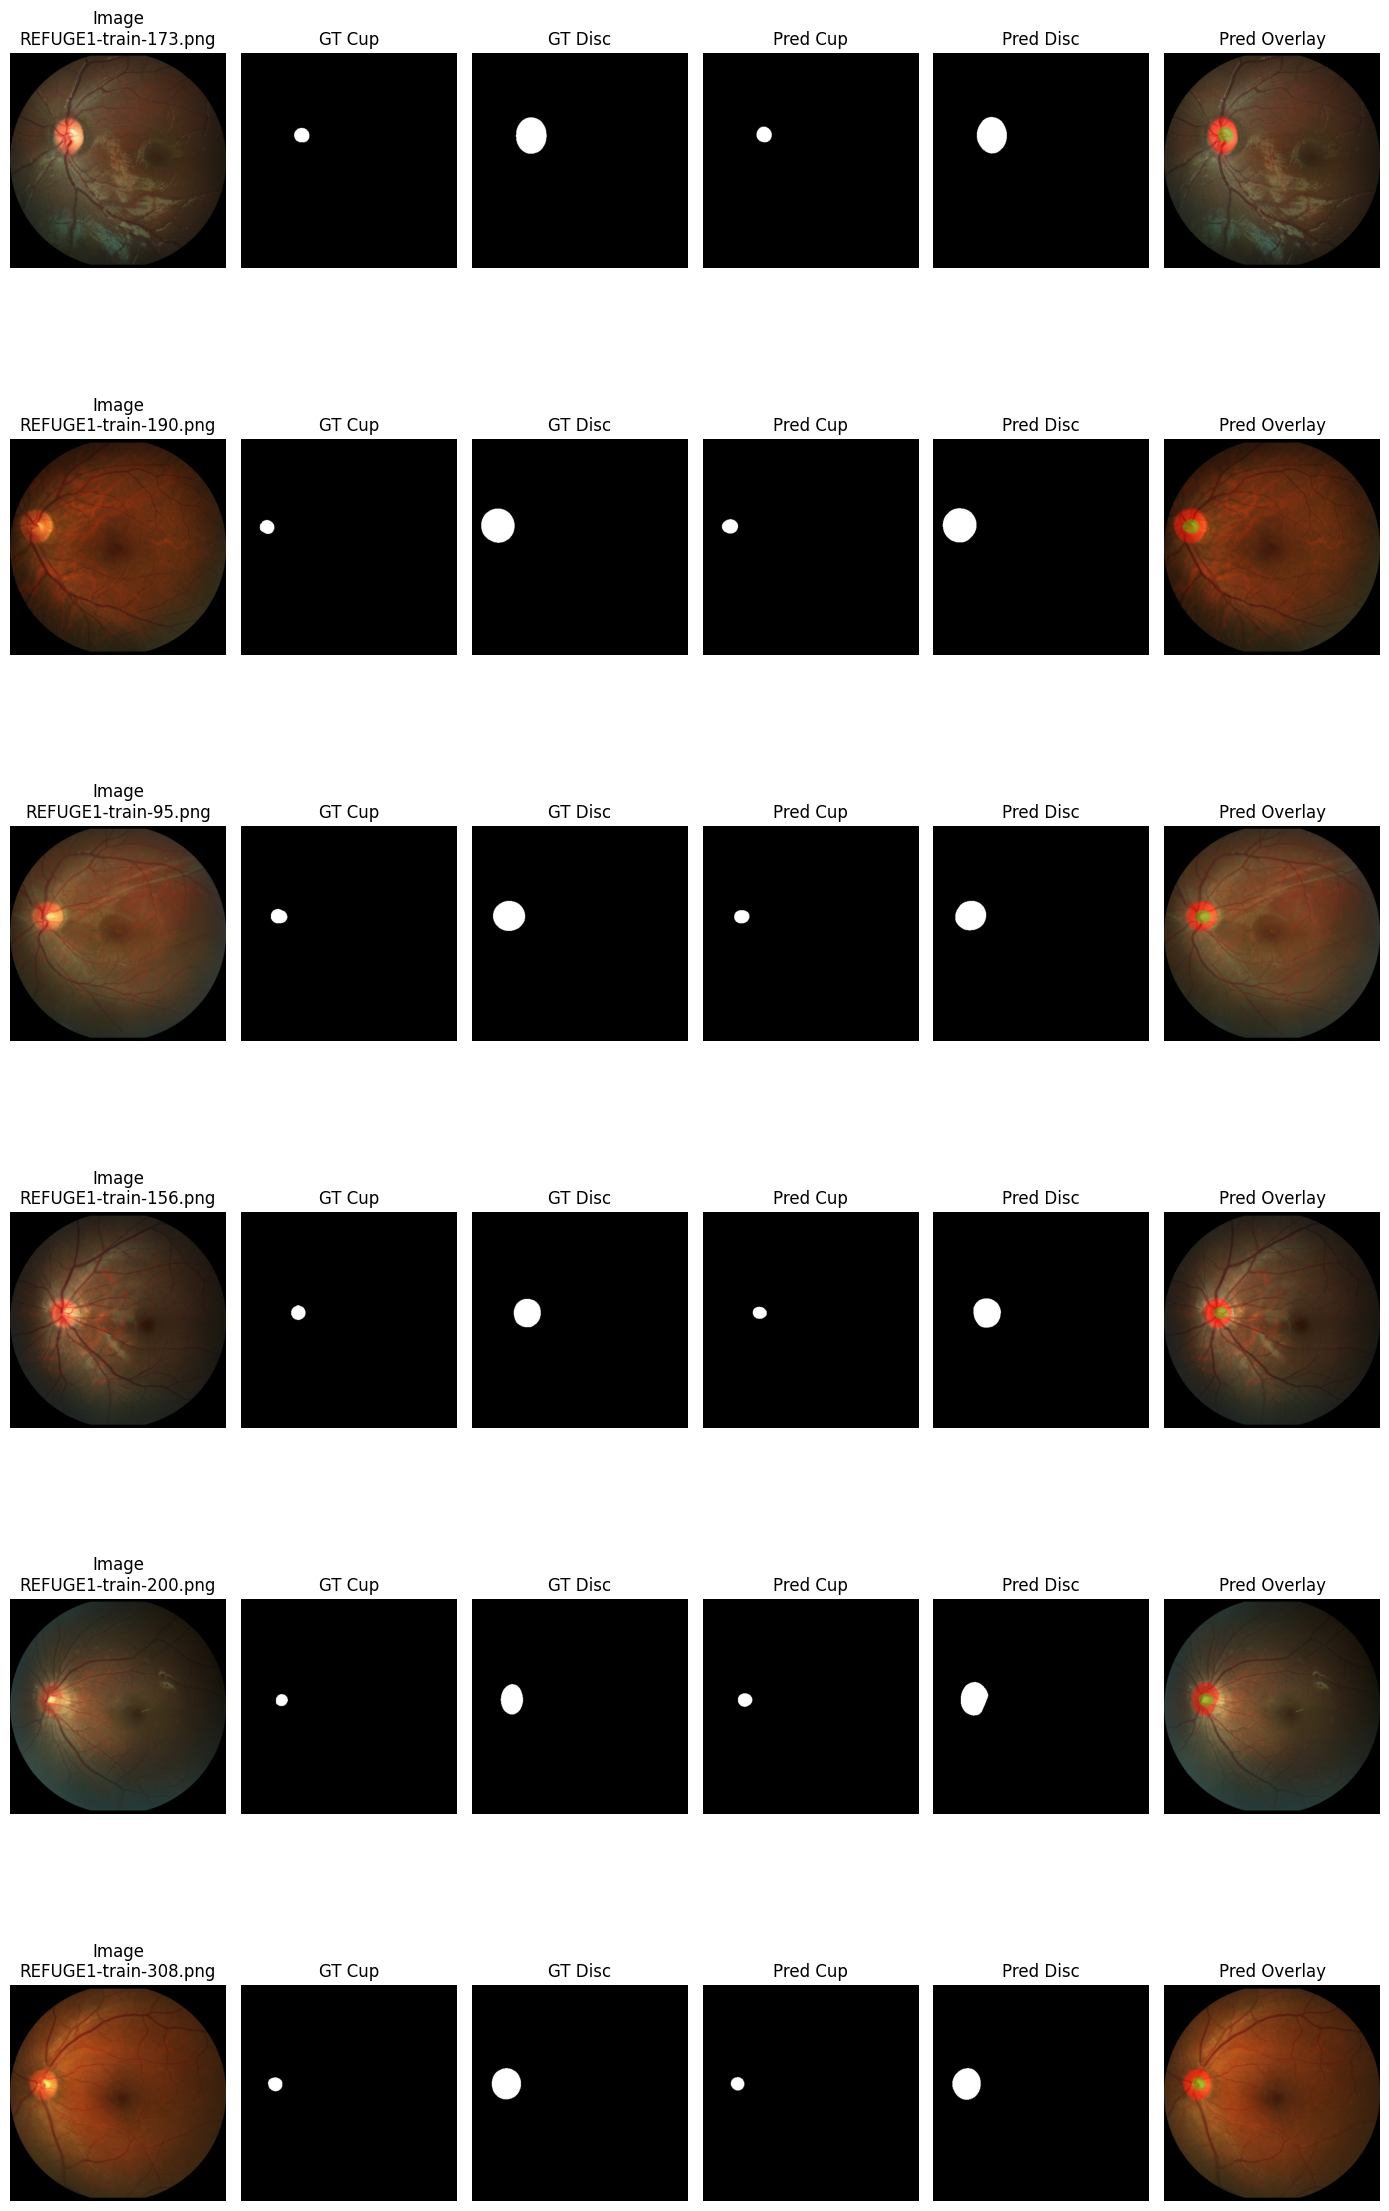

Preview saved: /content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/previews/test_prediction_preview.png


In [ ]:
def predict_single_image(model, image_path, img_size=512, threshold=0.5):
    image_rgb = read_rgb_cv(image_path)
    original_h, original_w = image_rgb.shape[:2]

    resized = cv2.resize(image_rgb, (img_size, img_size), interpolation=cv2.INTER_AREA)
    input_arr = resized.astype(np.float32)[None, ...]

    pred = model.predict(input_arr, verbose=0)[0]
    cup_pred = (pred[..., 0] >= threshold).astype(np.uint8)
    disc_pred = (pred[..., 1] >= threshold).astype(np.uint8)

    cup_pred_orig = cv2.resize(cup_pred, (original_w, original_h), interpolation=cv2.INTER_NEAREST)
    disc_pred_orig = cv2.resize(disc_pred, (original_w, original_h), interpolation=cv2.INTER_NEAREST)

    return image_rgb, cup_pred_orig, disc_pred_orig

sample_test = test_df.sample(n=min(6, len(test_df)), random_state=SEED)

plt.figure(figsize=(14, 4 * len(sample_test)))

for i, row in enumerate(sample_test.itertuples(index=False), start=1):
    img, cup_pred, disc_pred = predict_single_image(best_model, row.image_path, IMG_SIZE, threshold=0.5)

    gt_cup = binarize(read_gray_cv(row.cup_path))
    gt_disc = binarize(read_gray_cv(row.disc_path))

    overlay_pred = img.copy()
    overlay_pred[disc_pred > 0] = (0.65 * overlay_pred[disc_pred > 0] + 0.35 * np.array([255, 0, 0])).astype(np.uint8)
    overlay_pred[cup_pred > 0] = (0.65 * overlay_pred[cup_pred > 0] + 0.35 * np.array([0, 255, 0])).astype(np.uint8)

    plt.subplot(len(sample_test), 6, (i-1)*6 + 1)
    plt.imshow(img)
    plt.title(f"Image\n{row.filename}")
    plt.axis("off")

    plt.subplot(len(sample_test), 6, (i-1)*6 + 2)
    plt.imshow(gt_cup, cmap="gray")
    plt.title("GT Cup")
    plt.axis("off")

    plt.subplot(len(sample_test), 6, (i-1)*6 + 3)
    plt.imshow(gt_disc, cmap="gray")
    plt.title("GT Disc")
    plt.axis("off")

    plt.subplot(len(sample_test), 6, (i-1)*6 + 4)
    plt.imshow(cup_pred, cmap="gray")
    plt.title("Pred Cup")
    plt.axis("off")

    plt.subplot(len(sample_test), 6, (i-1)*6 + 5)
    plt.imshow(disc_pred, cmap="gray")
    plt.title("Pred Disc")
    plt.axis("off")

    plt.subplot(len(sample_test), 6, (i-1)*6 + 6)
    plt.imshow(overlay_pred)
    plt.title("Pred Overlay")
    plt.axis("off")

plt.tight_layout()
preview_path = os.path.join(PREVIEW_DIR, "test_prediction_preview.png")
plt.savefig(preview_path, dpi=200, bbox_inches="tight")
plt.show()
print("Preview saved:", preview_path)


## 12. Prediksi semua image REFUGE dan simpan pred_cup serta pred_disc

Output:
- `pred_cup/filename.png`
- `pred_disc/filename.png`

Mask disimpan sebagai binary image 0/255.


In [ ]:

prediction_rows = []

for row in tqdm(pairs_df.itertuples(index=False), total=len(pairs_df), desc="Predicting all REFUGE cup-disc masks"):
    img, cup_pred, disc_pred = predict_single_image(best_model, row.image_path, IMG_SIZE, threshold=0.5)

    cup_save = (cup_pred * 255).astype(np.uint8)
    disc_save = (disc_pred * 255).astype(np.uint8)

    cup_save_path = os.path.join(PRED_CUP_DIR, f"{row.name_no_ext}.png")
    disc_save_path = os.path.join(PRED_DISC_DIR, f"{row.name_no_ext}.png")

    cv2.imwrite(cup_save_path, cup_save)
    cv2.imwrite(disc_save_path, disc_save)

    prediction_rows.append({
        "name_no_ext": row.name_no_ext,
        "filename": row.filename,
        "image_path": row.image_path,
        "pred_cup_path": cup_save_path,
        "pred_disc_path": disc_save_path
    })

pred_df = pd.DataFrame(prediction_rows)
pred_csv_path = os.path.join(OUT_DIR, "predicted_cup_disc_paths.csv")
pred_df.to_csv(pred_csv_path, index=False)

print("Predicted masks saved:")
print("Cup :", PRED_CUP_DIR)
print("Disc:", PRED_DISC_DIR)
print("CSV :", pred_csv_path)
pred_df.head()


Predicting all REFUGE cup-disc masks:   0%|          | 0/400 [00:00<?, ?it/s]

Predicted masks saved:
Cup : /content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/pred_cup
Disc: /content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/pred_disc
CSV : /content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/predicted_cup_disc_paths.csv


,name_no_ext,filename,image_path,pred_cup_path,pred_disc_path
0,REFUGE1-train-1,REFUGE1-train-1.png,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/pred_mask_cup_di...,/content/drive/MyDrive/BV_CDR/pred_mask_cup_di...
1,REFUGE1-train-10,REFUGE1-train-10.png,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/pred_mask_cup_di...,/content/drive/MyDrive/BV_CDR/pred_mask_cup_di...
2,REFUGE1-train-100,REFUGE1-train-100.png,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/pred_mask_cup_di...,/content/drive/MyDrive/BV_CDR/pred_mask_cup_di...
3,REFUGE1-train-101,REFUGE1-train-101.png,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/pred_mask_cup_di...,/content/drive/MyDrive/BV_CDR/pred_mask_cup_di...
4,REFUGE1-train-102,REFUGE1-train-102.png,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/pred_mask_cup_di...,/content/drive/MyDrive/BV_CDR/pred_mask_cup_di...



## 13. Preview hasil prediksi semua data


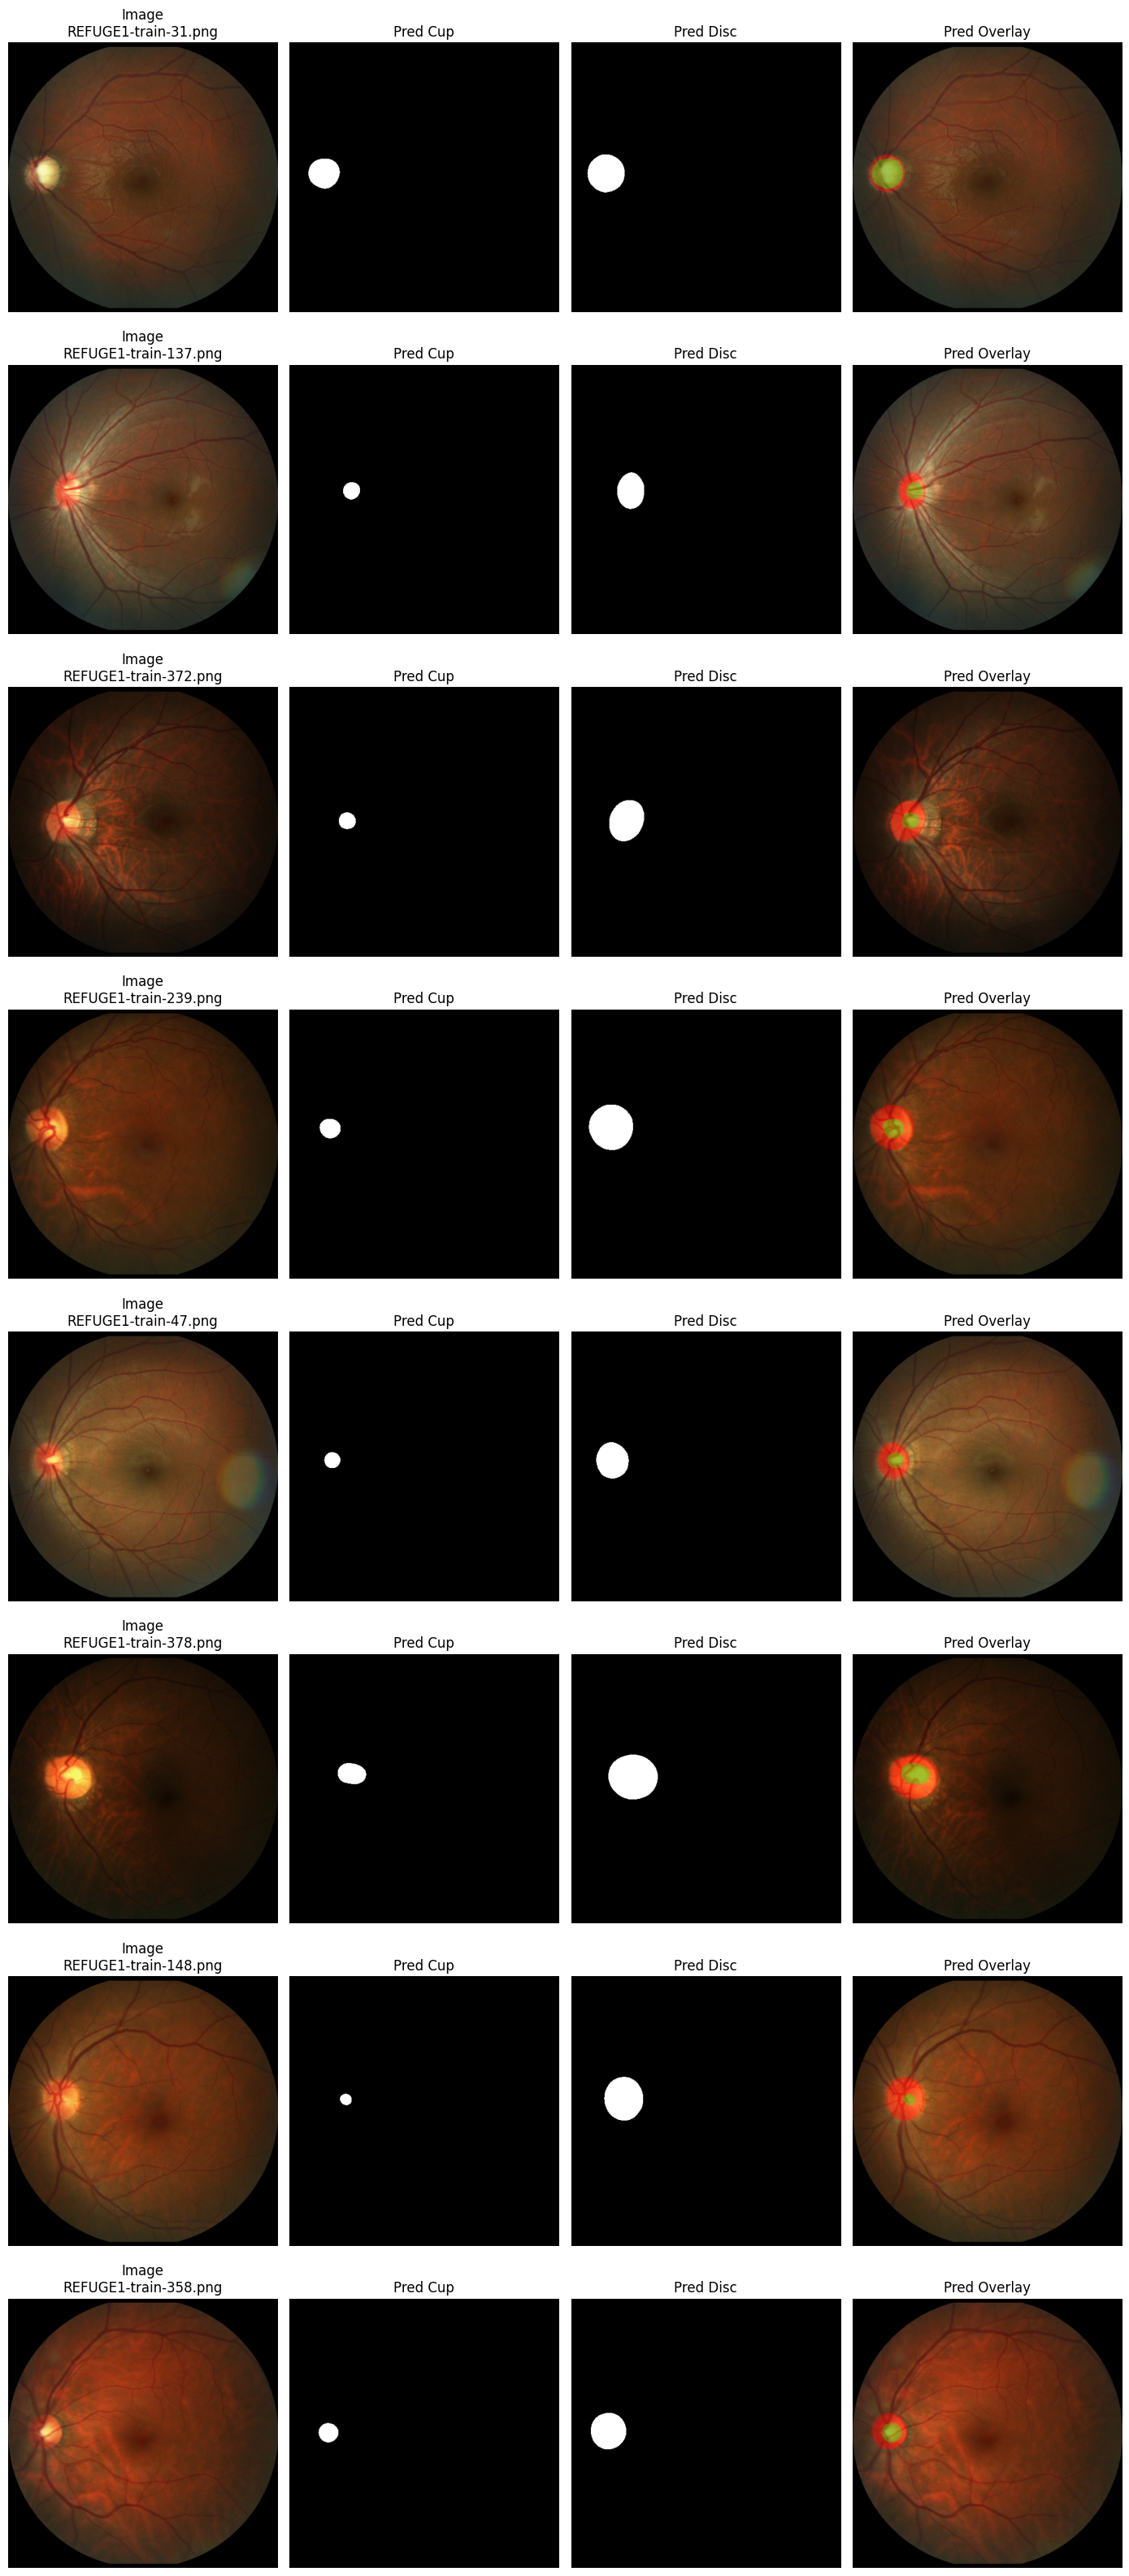

Preview saved: /content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/previews/all_prediction_preview.png


In [ ]:

preview_df = pred_df.sample(n=min(8, len(pred_df)), random_state=123)

plt.figure(figsize=(14, 4 * len(preview_df)))

for i, row in enumerate(preview_df.itertuples(index=False), start=1):
    img = read_rgb_cv(row.image_path)
    cup_pred = binarize(read_gray_cv(row.pred_cup_path))
    disc_pred = binarize(read_gray_cv(row.pred_disc_path))

    overlay = img.copy()
    overlay[disc_pred > 0] = (0.65 * overlay[disc_pred > 0] + 0.35 * np.array([255, 0, 0])).astype(np.uint8)
    overlay[cup_pred > 0] = (0.65 * overlay[cup_pred > 0] + 0.35 * np.array([0, 255, 0])).astype(np.uint8)

    plt.subplot(len(preview_df), 4, (i-1)*4 + 1)
    plt.imshow(img)
    plt.title(f"Image\n{row.filename}")
    plt.axis("off")

    plt.subplot(len(preview_df), 4, (i-1)*4 + 2)
    plt.imshow(cup_pred, cmap="gray")
    plt.title("Pred Cup")
    plt.axis("off")

    plt.subplot(len(preview_df), 4, (i-1)*4 + 3)
    plt.imshow(disc_pred, cmap="gray")
    plt.title("Pred Disc")
    plt.axis("off")

    plt.subplot(len(preview_df), 4, (i-1)*4 + 4)
    plt.imshow(overlay)
    plt.title("Pred Overlay")
    plt.axis("off")

plt.tight_layout()
preview_all_path = os.path.join(PREVIEW_DIR, "all_prediction_preview.png")
plt.savefig(preview_all_path, dpi=200, bbox_inches="tight")
plt.show()

print("Preview saved:", preview_all_path)



# Output utama

Setelah notebook selesai dijalankan, file penting ada di:

```text
/content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/pred_cup/
/content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/pred_disc/
/content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/best_model/best_unet_vgg16_cup_disc.keras
/content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/metrics/
/content/drive/MyDrive/BV_CDR/pred_mask_cup_disc/previews/
```

Catatan:
- `pred_cup` dan `pred_disc` adalah hasil prediksi model, bukan ground truth.
- Untuk pipeline otomatis berikutnya, gunakan folder `pred_cup` dan `pred_disc` sebagai mask hasil segmentasi.
